# THUNDER4D tutorial

*Transverse-resolved Herriott-cell UPPE solver for Nonlinear Dynamics close to Experimental Reality, 4D*

This notebook walks through the code step by step, from the gas to a full multipass-cell simulation:

1. setup and device (CPU or GPU)
2. the nonlinear medium
3. the cell: geometry, eigenmode, nonlinear mode matching
4. the grid and its conventions
5. the pulse: spectrum, spatial profiles (incl. Laguerre–Gauss), aberrations, space-time couplings
6. injecting the beam into the cell
7. running a simulation
8. analysing the results
9. saving, checkpoints, and running on a GPU

Every simulation here uses a small near-planar test cell so that the whole notebook runs in a few minutes on a laptop CPU. Change the parameters freely: each section is self-contained once the cells above it have run.

## 1. Setup and device

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

# the notebook lives in examples/: make the package importable without installing it
sys.path.insert(0, os.path.abspath(".."))
import thunder4d as th
from thunder4d import diagnostics as dg

DEVICE = "cpu"      # "auto" = GPU if CuPy works, else CPU; or force "cpu" / "gpu"
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (9, 3.4)})

## 2. The nonlinear medium

`Material` gives the refractive index (Sellmeier formula of Börzsönyi *et al.* 2008) and the nonlinear index $n_2$, both scaled with pressure. `critical_power` is the Gaussian-beam self-focusing power $P_c = \lambda^2/(2\pi n_0 n_2)$.

In [2]:
for p_bar in (0.5, 1.0, 5.0):
    gas = th.Material("Ar", pressure_bar=p_bar)
    lam = 1030e-9
    w = 2 * np.pi * th.C0 / lam
    print(f"Ar {p_bar:3.1f} bar: n-1 = {gas.n(w)-1:.3e}, n2 = {gas.n2:.2e} m^2/W, "
          f"GVD = {gas.gvd(lam):5.1f} fs^2/m, Pc = {gas.critical_power(lam)/1e9:5.2f} GW")

gas = th.Material("Ar", 1.0, n2_1bar=1.0e-23)

Ar 0.5 bar: n-1 = 1.282e-04, n2 = 5.00e-24 m^2/W, GVD =   7.0 fs^2/m, Pc = 33.77 GW
Ar 1.0 bar: n-1 = 2.565e-04, n2 = 1.00e-23 m^2/W, GVD =  13.9 fs^2/m, Pc = 16.88 GW
Ar 5.0 bar: n-1 = 1.282e-03, n2 = 5.00e-23 m^2/W, GVD =  69.4 fs^2/m, Pc =  3.37 GW


## 3. The multipass cell

### Geometry
`MPC.herriott(R, N, k, ...)` builds a re-entrant Herriott cell that closes on itself after N passes, with a Gouy phase of $2\pi k/N$ per pass for the near-planar branch. Two mirror separations give the same spot pattern: **near-concentric** $d = R[1+\cos(2\pi k/N)]$ (default, usual for high energy) and **near-planar** $d = R[1-\cos(2\pi k/N)]$. Any separation can also be given directly with `MPC(R, d, medium, n_passes)`.

In [3]:
for branch in ("concentric", "planar"):
    c = th.MPC.herriott(R=2.0, N=30, k=2, medium=gas, branch=branch)
    m = c.linear_mode(1030e-9)
    print(f"{branch:10s}: d = {c.d:.3f} m, Gouy phase/pass = {np.degrees(c.theta):5.1f} deg, "
          f"waist {m['w0']*1e6:.0f} um, mirror spot {m['w_mirror']*1e6:.0f} um")

concentric: d = 3.827 m, Gouy phase/pass = 156.0 deg, waist 365 um, mirror spot 1756 um
planar    : d = 0.173 m, Gouy phase/pass =  24.0 deg, waist 365 um, mirror spot 373 um


For this tutorial we use a small near-planar cell (R = 0.5 m, 10 passes) that is cheap to simulate.

### Eigenmode and nonlinear mode matching
The Kerr lens of the gas shrinks the stationary beam of the cell. In the aberration-free model a Gaussian beam of power $P$ behaves like a linear beam of wavelength $\lambda\sqrt{1-P/P_c}$, so the matched waist and mirror spot scale as $(1-P/P_c)^{1/4}$ (Hanna *et al.*, JOSA B 2017; OSA Continuum 2021).

In [4]:
cell = th.MPC.herriott(R=0.5, N=20, k=3, medium=gas, branch="planar", n_passes=10)
print(cell.report())

Pc = gas.critical_power(1030e-9)
for r in (0.0, 0.2, 0.4, 0.6):
    m = cell.nonlinear_mode(max(r, 1e-6) * Pc, 1030e-9)
    print(f"P/Pc = {r:.1f}: matched waist {m['w0']*1e6:5.1f} um, mirror {m['w_mirror']*1e6:5.1f} um, "
          f"B/pass ~ {m['B_per_pass']:.2f} rad")

MPC: R = 0.500 m, d = 0.2061 m, 10 passes, Gouy/pass = 54.00 deg, Material(Ar, 1.0 bar, n2 = 1e-23 m^2/W)
P/Pc = 0.0: matched waist 257.5 um, mirror 289.0 um, B/pass ~ 0.00 rad
P/Pc = 0.2: matched waist 243.5 um, mirror 273.3 um, B/pass ~ 0.42 rad
P/Pc = 0.4: matched waist 226.6 um, mirror 254.3 um, B/pass ~ 0.97 rad
P/Pc = 0.6: matched waist 204.8 um, mirror 229.8 um, B/pass ~ 1.79 rad


## 4. The grid

`suggest_grid` sizes the box from the mirror spot, the transverse step from the waist and the mirror curvature, and the time step from the spectral window you ask for.

**Conventions** (worth remembering):
* the field `Aw` has shape `(Nx, Ny, Nt)` and lives in the mixed domain $(x, y, \Omega)$;
* all arrays are in **FFT order** (index 0 is $x=0$, $t=0$, $\Omega=0$); use the sorted versions `grid.xs`, `grid.ts`, `grid.lams` for plotting. All `diagnostics` functions already return sorted axes;
* $|A|^2$ is the intensity in W/m²; positive GDD is an up-chirp.

In [5]:
grid = th.suggest_grid(cell, lambda0=1030e-9, lambda_min=920e-9, lambda_max=1160e-9,
                       pulse_fwhm=200e-15, box_factor=10)
print(grid.describe())
print("x (FFT order), first values [um]:", np.round(grid.x[:4] * 1e6, 1))
print("x sorted, first values [um]:     ", np.round(grid.xs[:4] * 1e6, 1))

Grid 108x108x120 (11 MB per field) | box 3.07 x 3.07 mm, dx = 28.4 um | T = 1724 fs, dt = 14.37 fs | lambda window 922-1170 nm
x (FFT order), first values [um]: [ 0.  28.4 56.8 85.2]
x sorted, first values [um]:      [-1533.3 -1504.9 -1476.5 -1448.1]


## 5. The pulse

A pulse is $A(x, y, \Omega) = E(\Omega)\,U(x, y;\Omega)$: a 1D spectral amplitude times a spatial field (which may depend on the colour).

### 5.1 Spectrum and spectral phase

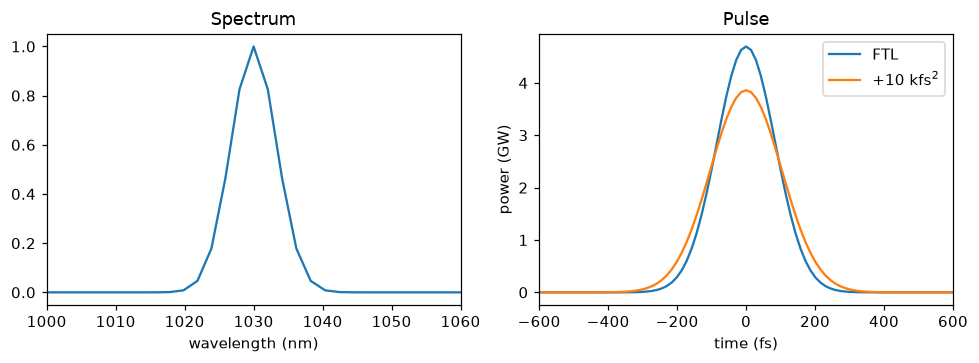

In [6]:
E_tl = th.gaussian_spectrum(grid, fwhm_fs=200)
E_ch = th.add_spectral_phase(grid, E_tl, gdd_fs2=10000, tod_fs3=0)
# other options: th.measured_spectrum(grid, wl_nm, I, phase_rad=...), th.spectrum_from_temporal_field(...)

i = np.argsort(grid.lam)
fig, ax = plt.subplots(1, 2)
ax[0].plot(grid.lam[i] * 1e9, np.abs(E_tl[i]) ** 2 / np.abs(E_tl).max() ** 2)
ax[0].set_xlim(1000, 1060); ax[0].set_xlabel("wavelength (nm)"); ax[0].set_title("Spectrum")
for E, lab in ((E_tl, "FTL"), (E_ch, "+10 kfs$^2$")):
    p = th.Pulse.at_focus(grid, E, th.Beam(th.gaussian(200e-6)), 1e-3)
    t, P = dg.temporal_power(grid, p.Aw)
    ax[1].plot(t * 1e15, P / 1e9, label=lab)
ax[1].set_xlim(-600, 600); ax[1].set_xlabel("time (fs)"); ax[1].set_ylabel("power (GW)"); ax[1].set_title("Pulse"); ax[1].legend()
plt.tight_layout()

### 5.2 Spatial profiles
A `Profile` is just a function of $(X, Y)$. Laguerre–Gauss and Hermite–Gauss modes are normalised, so the squared amplitudes of a `mode_superposition` are power fractions.

[Text(1, -3.141592653589793, '$-\\pi$'),
 Text(1, 0.0, '0'),
 Text(1, 3.141592653589793, '$\\pi$')]

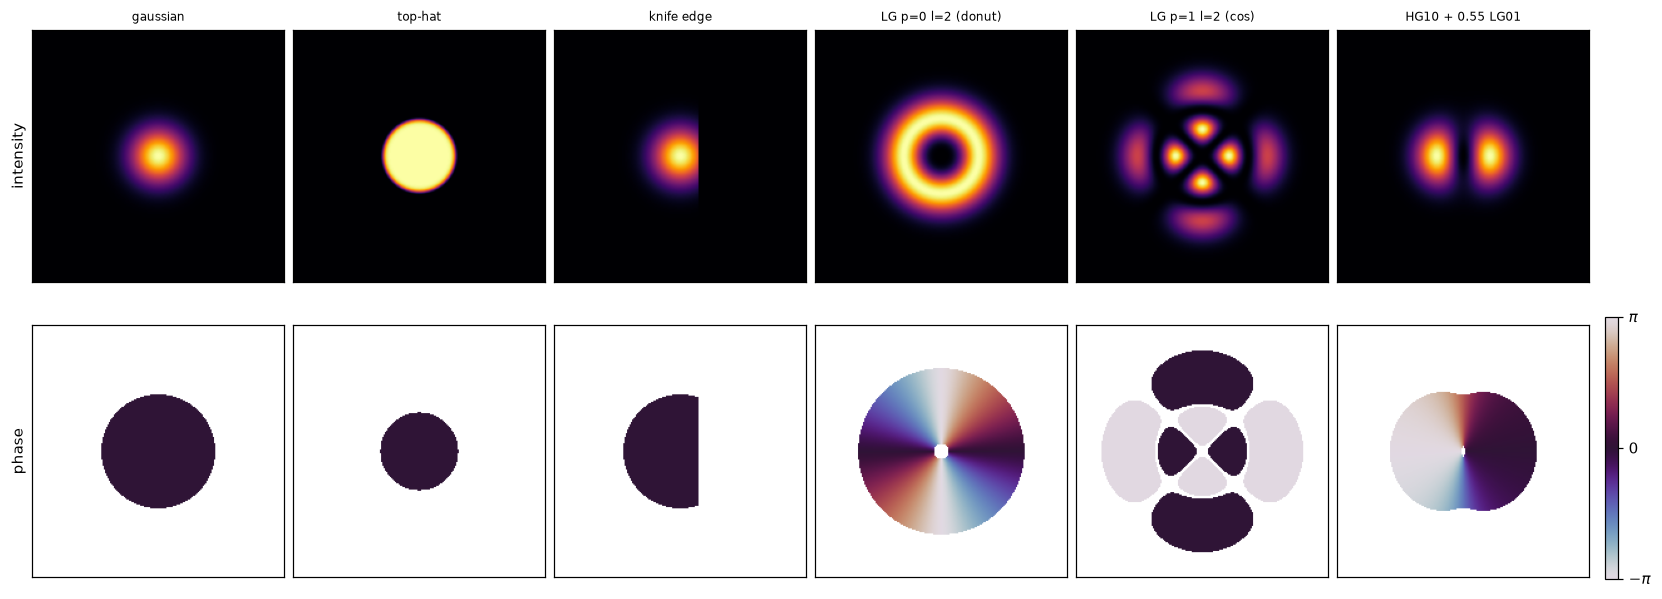

In [7]:
w = 300e-6
profiles = {
    "gaussian": th.gaussian(w),
    "top-hat": th.top_hat(w),
    "knife edge": th.knife_edge(th.gaussian(w), 0.5 * w, axis="x", side="+"),
    "LG p=0 l=2 (donut)": th.laguerre_gauss(w, p=0, l=2),
    "LG p=1 l=2 (cos)": th.laguerre_gauss(w, p=1, l=2, kind="cos"),
    "HG10 + 0.55 LG01": th.mode_superposition([(1.0, th.hermite_gauss(w, 1, 0)),
                                               (0.55, th.laguerre_gauss(w, 0, 1))]),
}
x = np.linspace(-1e-3, 1e-3, 201)
X, Y = x[:, None], x[None, :]
fig, axs = plt.subplots(2, len(profiles), figsize=(15, 5.4), layout="constrained")
for (a_int, a_ph), (name, prof) in zip(axs.T, profiles.items()):
    U = prof(X, Y)
    I = np.abs(U) ** 2
    a_int.imshow(I.T, origin="lower", extent=[-1, 1, -1, 1], cmap="inferno")
    a_int.set_title(name, fontsize=8)
    # phase only where there is light (< 1% of the peak intensity is masked)
    ph = np.ma.masked_where(I < 1e-2 * I.max(), np.angle(U))
    im = a_ph.imshow(ph.T, origin="lower", extent=[-1, 1, -1, 1], cmap="twilight",
                     vmin=-np.pi, vmax=np.pi)
    for a in (a_int, a_ph):
        a.set_xticks([]); a.set_yticks([])
axs[0, 0].set_ylabel("intensity"); axs[1, 0].set_ylabel("phase")
fig.colorbar(im, ax=axs, ticks=[-np.pi, 0, np.pi], shrink=0.45, anchor=(0, 0.05), pad=0.01).ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])

### 5.3 Aberrations and space-time couplings
A `Beam` combines a profile with Zernike aberrations (RMS waves at $\lambda_0$, applied as an achromatic wavefront) and space-time couplings: spatial chirp, angular dispersion, pulse-front tilt and curvature, radial GDD, or any custom phase. `chromatic_size` makes the spot size scale with wavelength like the cell eigenmode (`"eigenmode"`) or a focused beam (`"focus"`).

Here a spatial chirp of 0.01 mm/nm shows up directly in the spatio-spectral trace $S(x,\lambda)$:

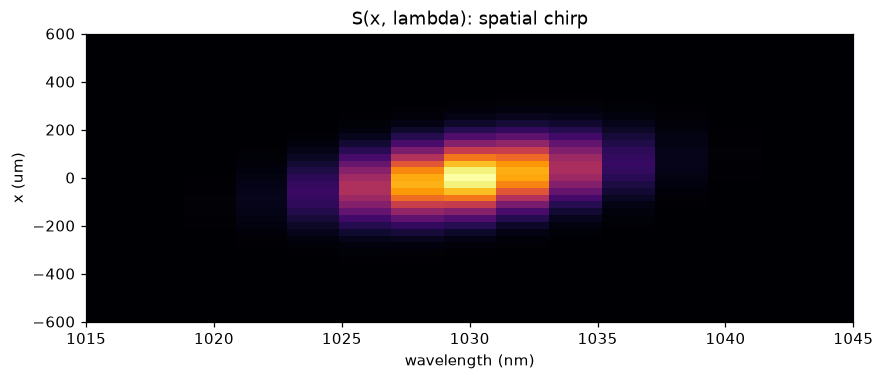

In [8]:
beam = th.Beam(th.gaussian(200e-6), spatial_chirp_mm_per_nm=(0.01, 0.0),
               zernike={"astig_0": 0.05}, pupil_radius=400e-6)
p = th.Pulse.at_focus(grid, E_tl, beam, 1e-3)
xs, lam, S = dg.spectrogram_x_lambda(grid, p.Aw)
plt.pcolormesh(lam * 1e9, xs * 1e6, S / S.max(), shading="auto", cmap="inferno")
plt.xlim(1015, 1045); plt.ylim(-600, 600)
plt.xlabel("wavelength (nm)"); plt.ylabel("x (um)"); plt.title("S(x, lambda): spatial chirp");

## 6. Injecting the beam into the cell

The simulation starts at the cell centre. Three builders define where your beam is specified:

| builder | beam defined | typical use |
|---|---|---|
| `Pulse.at_focus` | at the cell centre | ideal matched Gaussian |
| `Pulse.from_near_field` | collimated near field, focused by a lens (exact per-colour Fourier transform) | top-hat near field → Airy pattern at the centre |
| `Pulse.imaged_near_field` | near field imaged onto the mirror, then propagated back | flat-top on the input mirror |

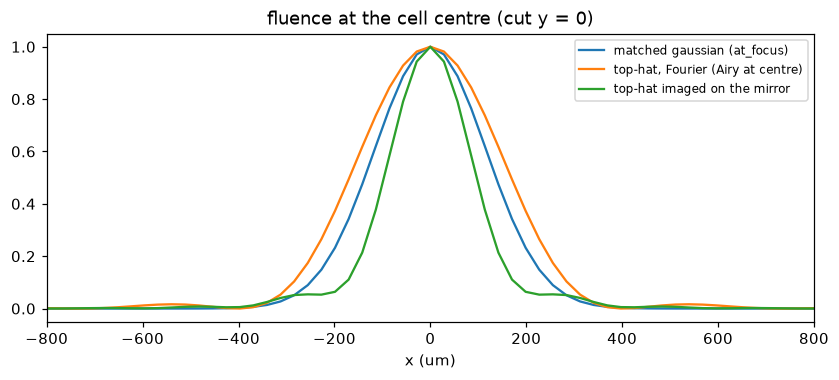

In [9]:
probe = th.Pulse.at_focus(grid, E_tl, th.Beam(th.gaussian(1e-3)), 1.2e-3)
mm = cell.match(probe, verbose=False)

inputs = {
    "matched gaussian (at_focus)": th.Pulse.at_focus(
        grid, E_tl, th.Beam(th.gaussian(mm["w0"]), chromatic_size="eigenmode"), 1.2e-3),
    "top-hat, Fourier (Airy at centre)": th.Pulse.from_near_field(
        grid, E_tl, th.Beam(th.top_hat(4e-3)), 1.2e-3, nf_size=12e-3, nf_points=160,
        target_waist=mm["w0"], verbose=False),
    "top-hat imaged on the mirror": th.Pulse.imaged_near_field(
        grid, E_tl, th.Beam(th.top_hat(1.12 * mm["w_mirror"])), 1.2e-3, cell, verbose=False),
}
for name, p in inputs.items():
    F = dg.fluence(grid, p.Aw)
    plt.plot(grid.xs * 1e6, F[:, grid.Ny // 2] / F.max(), label=name)
plt.xlim(-800, 800); plt.xlabel("x (um)"); plt.title("fluence at the cell centre (cut y = 0)"); plt.legend(fontsize=8);

## 7. Running a simulation

`MPCSimulation` propagates pass by pass (centre → mirror → centre) and records diagnostics after every pass. `profile_wavelengths` adds 1D beam profiles of selected colours (bandpass `profile_bandwidth`) at the centre, the mirror and in the far field.

`phi_max` (peak nonlinear phase per step) controls accuracy: halve it to check convergence.

In [11]:
pulse = inputs["matched gaussian (at_focus)"]
sim = th.MPCSimulation(pulse, cell, phi_max=0.02, mode_reference=mm["w0"],
                       profile_wavelengths=[1015e-9, 1030e-9, 1045e-9], profile_bandwidth=2e-9)
t0 = time.time()
sim.run()                       # all passes; sim.run(n_passes=1) to go step by step
print(f"{cell.n_passes} passes in {time.time() - t0:.0f} s")

pass   1/10 | B =   0.84 rad | E = 1.2 mJ | eta00 = 0.9943 | V_near = 0.9984 | V_far = 0.9980 | M2 = 1.004/1.004 | steps 47 | 4 s
pass   2/10 | B =   1.67 rad | E = 1.2 mJ | eta00 = 0.9928 | V_near = 0.9993 | V_far = 0.9994 | M2 = 1.004/1.004 | steps 93 | 7 s
pass   3/10 | B =   2.52 rad | E = 1.2 mJ | eta00 = 0.9989 | V_near = 0.9998 | V_far = 0.9998 | M2 = 1.002/1.002 | steps 139 | 11 s
pass   4/10 | B =   3.34 rad | E = 1.2 mJ | eta00 = 0.9962 | V_near = 0.9990 | V_far = 0.9989 | M2 = 1.005/1.005 | steps 185 | 15 s
pass   5/10 | B =   4.17 rad | E = 1.2 mJ | eta00 = 0.9923 | V_near = 0.9997 | V_far = 0.9997 | M2 = 1.002/1.002 | steps 231 | 18 s
pass   6/10 | B =   5.02 rad | E = 1.2 mJ | eta00 = 0.9964 | V_near = 0.9994 | V_far = 0.9994 | M2 = 1.005/1.005 | steps 278 | 22 s
pass   7/10 | B =   5.83 rad | E = 1.2 mJ | eta00 = 0.9983 | V_near = 0.9996 | V_far = 0.9997 | M2 = 1.005/1.005 | steps 324 | 26 s
pass   8/10 | B =   6.67 rad | E = 1.2 mJ | eta00 = 0.9930 | V_near = 0.9997 | V

## 8. Analysing the results

### 8.1 Per-pass history

recorded keys: B, M2x, M2x_mean, M2y, M2y_mean, V_far, V_near, band_energy, energy, eta00, eta00_total, fluence, fluence_mirror, order_frac, pass, peak_power, prof_far, prof_mirror, prof_near, prof_near_proj, sgram_theta, sgram_x, spectrum, wall_s, wx, wy


KeyError: 'w_peak_x'

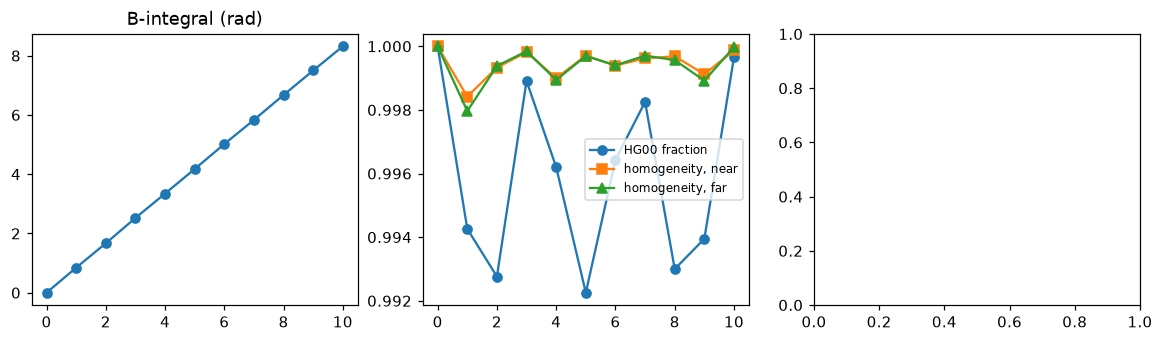

In [12]:
h = sim.history
print("recorded keys:", ", ".join(sorted(h)))
P = np.array(h["pass"])
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot(P, h["B"], "o-"); ax[0].set_title("B-integral (rad)")
ax[1].plot(P, h["eta00_total"], "o-", label="HG00 fraction")
ax[1].plot(P, h["V_near"], "s-", label="homogeneity, near")
ax[1].plot(P, h["V_far"], "^-", label="homogeneity, far"); ax[1].legend(fontsize=8)
ax[2].plot(P, np.array(h["w_peak_x"]) * 1e6, "o-"); ax[2].set_title("beam radius, peak slice (um)")
for a in ax: a.set_xlabel("pass")
plt.tight_layout()

### 8.2 Spectra and spatio-spectral traces

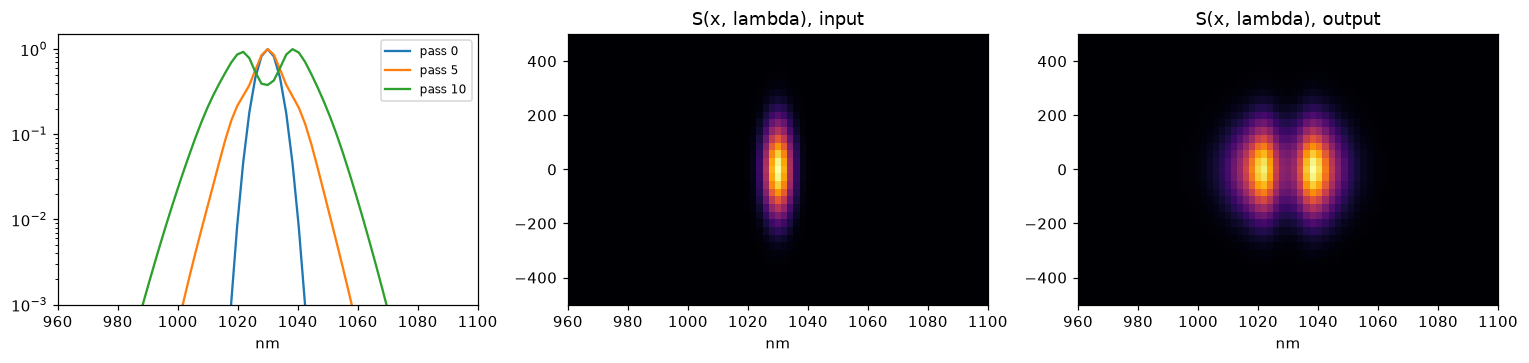

In [13]:
lam = sim.lam
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
for k in (0, len(P) // 2, len(P) - 1):
    S = h["spectrum"][k]
    ax[0].semilogy(lam * 1e9, S / S.max(), label=f"pass {P[k]}")
ax[0].set_ylim(1e-3, 1.5); ax[0].set_xlim(960, 1100); ax[0].set_xlabel("nm"); ax[0].legend(fontsize=8)
for a, k, t in ((ax[1], 0, "input"), (ax[2], -1, "output")):
    S = h["sgram_x"][k]
    a.pcolormesh(lam * 1e9, sim.x * 1e6, S / S.max(), shading="auto", cmap="inferno")
    a.set_xlim(960, 1100); a.set_ylim(-500, 500); a.set_title(f"S(x, lambda), {t}"); a.set_xlabel("nm")
plt.tight_layout()

### 8.3 Beam profiles of individual colours

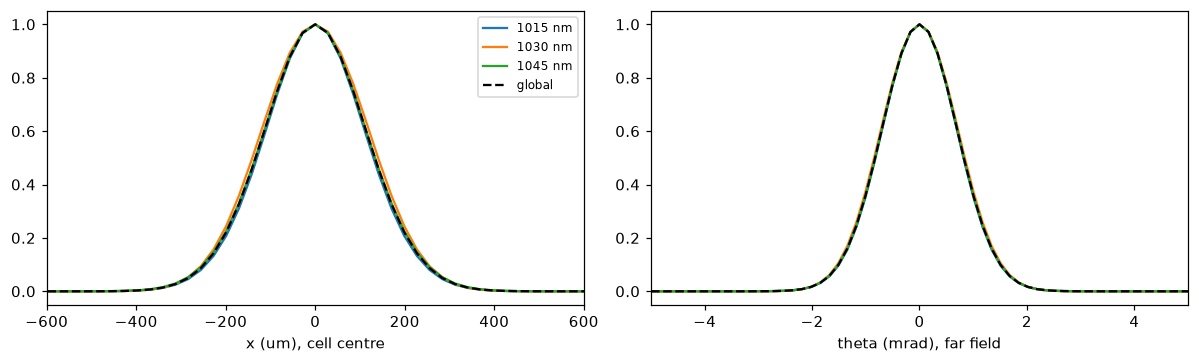

In [14]:
labels = ["1015 nm", "1030 nm", "1045 nm", "global"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for i, lab in enumerate(labels):
    for a, key, coord in ((ax[0], "prof_near", sim.prof_coord * 1e6), (ax[1], "prof_far", sim.theta * 1e3)):
        y = np.array(h[key][-1][i], float)
        a.plot(coord, y / y.max(), "k--" if lab == "global" else "-", label=lab)
ax[0].set_xlim(-600, 600); ax[0].set_xlabel("x (um), cell centre")
ax[1].set_xlim(-5, 5); ax[1].set_xlabel("theta (mrad), far field"); ax[0].legend(fontsize=8)
plt.tight_layout()

### 8.4 Compression, chirp map, modal content

In [15]:
c = dg.compress(grid, sim.Aw)
print(f"compressed: {c['fwhm_fs']:.1f} fs with {c['gdd_fs2']:.0f} fs^2 (transform limit {c['tl_fwhm_fs']:.1f} fs)")

gdd = dg.local_gdd_map(grid, sim.Aw)
r, g = dg.radial_profile(grid, gdd)
lg = dg.lg_mode_content(grid, sim.Aw, lambda l: mm["w0"] * np.sqrt(l / 1030e-9), p_max=1, l_max=1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(c["t_fs"], c["P"] / 1e9); ax[0].set_xlim(-200, 200)
ax[0].set_xlabel("time (fs)"); ax[0].set_ylabel("power (GW)"); ax[0].set_title("compressed pulse")
ax[1].plot(r * 1e6, g); ax[1].set_xlim(0, 2 * mm["w0"] * 1e6)
ax[1].set_xlabel("r (um)"); ax[1].set_ylabel("local GDD (fs$^2$)"); ax[1].set_title("radial chirp")
plt.tight_layout()
print("LG content [p, l] (l = -1, 0, 1):\n", np.round(lg["frac"], 4))

compressed: 63.5 fs with -2335 fs^2 (transform limit 58.7 fs)


AttributeError: module 'thunder4d.diagnostics' has no attribute 'lg_mode_content'

## 9. Saving, checkpoints and the GPU

* `sim.save("run.npz")` writes the history, axes and metadata (and the final field) as NumPy arrays.
* `sim.checkpoint(path)` / `sim.resume(path)` and `sim.run(max_seconds=...)` split long runs.
* Everything returned by the diagnostics is a NumPy array, whether the run used the CPU or the GPU. `th.to_host(sim.Aw)` gives the field itself.

In [15]:
sim.save("tutorial_run.npz", include_field=False)
d = np.load("tutorial_run.npz")
print("saved:", ", ".join(sorted(d.files))[:300], "...")
os.remove("tutorial_run.npz")

saved: B, I_peak, M2x, M2x_mean, M2y, M2y_mean, R, V_far, V_near, band_energy, d, device, energy, eta00, eta00_total, fluence, fluence_mirror, gas, grid, lam, lambda0, n2, n_passes, order_frac, pass, peak_power, pressure_bar, prof_bandwidth, prof_coord, prof_far, prof_mirror, prof_near, prof_near_proj, pro ...


### Running on a GPU
With an NVIDIA GPU and CuPy installed (`pip install cupy-cuda12x`; RTX 50-series cards need CUDA ≥ 12.8), `device="auto"` already uses it. The cell below times one pass on each available device for the same problem.

In [16]:
def time_one_pass(device):
    g = th.suggest_grid(cell, 1030e-9, 920e-9, 1160e-9, 200e-15, box_factor=10, device=device)
    E = th.gaussian_spectrum(g, fwhm_fs=200)
    p = th.Pulse.at_focus(g, E, th.Beam(th.gaussian(mm["w0"])), 1.2e-3)
    s = th.MPCSimulation(p, cell, phi_max=0.02, far_field=False, record_mirror=False)
    t0 = time.time(); s.run(n_passes=1, verbose=False)
    return time.time() - t0

print(f"CPU: {time_one_pass('cpu'):.1f} s per pass")
if th.gpu_available():
    time_one_pass("gpu")                                  # first call compiles the GPU kernels
    print(f"GPU: {time_one_pass('gpu'):.2f} s per pass")
else:
    print("no GPU found: install CuPy to compare")

CPU: 8.9 s per pass
no GPU found: install CuPy to compare


## Exercises

1. **Mode mismatch**: inject the *linear* waist `cell.linear_mode(1030e-9)["w0"]` instead of `mm["w0"]` and plot `w_peak_x` versus pass (compare with `examples/benchmarks/hanna2021_nlbm.py`).
2. **Top-hat cleaning**: run the two top-hat inputs of section 6 and compare `eta00_total`, `V_far` and the per-colour profiles with the Gaussian.
3. **Donut mode**: replace the Gaussian with `th.laguerre_gauss(mm["w0"], 0, 1)` and follow `dg.lg_mode_content` pass after pass (see `examples/lg_donut_mpc.py`).
4. **Space-time couplings**: add a pulse-front tilt (`pft_fs_per_mm=(2, 0)`) and see how it evolves in `sgram_theta`.
5. **Convergence**: rerun with `phi_max=0.01` and compare the output spectrum.